# 17 - Embedding and Immersion: Practical Whitney

In surgery theory, we often need to represent abstract homology classes as embedded sub-manifolds. The **Whitney Embedding Theorem** tells us that every smooth $n$-manifold can be embedded in $\mathbb{R}^{2n}$. In this notebook, we explore the piecewise linear (PL) version of these results, focusing on detecting self-intersections and verifying when a mapping is a true embedding or just an immersion.

## Learning Goals
- **Represent PL Maps**: Use the `PLMap` class to define mappings from simplicial complexes to Euclidean space.
- **Verify Immersions**: Check if a map is locally injective (non-singular derivative in the PL sense).
- **Detect Self-Intersections**: Identify where different simplices overlap in the target space.
- **Whitney Trick Intuition**: Understand how self-intersections can be removed algebraically and geometrically.
- **Visualize Embeddings**: Plot 1D and 2D complexes embedded in $\mathbb{R}^2$ and $\mathbb{R}^3$.

## Formal Grounding

### Immersions vs. Embeddings
Let $f: M \to N$ be a PL map.
- **Immersion**: $f$ is locally injective. For every point $x \in M$, there is a neighborhood where $f$ is an embedding.
- **Embedding**: $f$ is an immersion and is globally injective (homeomorphism onto its image).

### The Self-Intersection Set
For an immersion $f$, the self-intersection set is:
$$ \Sigma(f) = \{ (x, y) \in M \times M \mid x \neq y, f(x) = f(y) \} $$
In surgery theory, if the components of $\Sigma(f)$ can be paired up with opposite signs (the **Whitney Trick**), they can be cancelled out to produce an embedding.

| Property | PL Check | Topological Significance |
|---|---|---|
| **Local Injective** | `check_immersion` | Non-degenerate simplices in target |
| **Global Injective**| `detect_self_intersections` | Essential for representability of classes |
| **Codimension** | $dim(N) - dim(M)$ | Determines the difficulty of removing intersections |


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pysurgery as ps
from pysurgery.core.embedding import PLMap, analyze_embedding, detect_self_intersections

print('=' * 70)
print('17 - Embedding and Immersion: Setup Complete')
print('=' * 70)

17 - Embedding and Immersion: Setup Complete


## Part 1: Defining Piecewise Linear Maps

A `PLMap` consists of a source simplicial complex and a set of coordinates for each vertex in the target space $\mathbb{R}^k$.


### Example 17.1: Standard Embedding of $S^1$ in $\mathbb{R}^2$

In [4]:
# Source: Circle with 3 vertices
sc_s1 = ps.SimplicialComplex.from_maximal_simplices([(0,1), (1,2), (2,0)])

# Target coordinates: Equilateral triangle in R2
coords = np.array([
    [1.0, 0.0],
    [-0.5, 0.866],
    [-0.5, -0.866]
])

pl_map = PLMap.from_source(sc_s1, coordinates=coords)
res = analyze_embedding(sc_s1, coordinates=coords)

print('S1 Mapping Status:')
print(f'  Is Immersion? {res.immersion.immersed}')
print(f'  Is Embedding? {res.embedded}')
print(f'  Self-intersections found: {len(res.intersections)}')

S1 Mapping Status:
  Is Immersion? True
  Is Embedding? True
  Self-intersections found: 0


## Part 2: Immersions and Self-Intersections

An immersion might fail to be an embedding if it "crosses itself."


### Example 17.2: Figure-Eight Immersion of $S^1$ in $\mathbb{R}^2$

In [7]:
# We use the same circle source but different coordinates
# (0,1) and (1,2) will cross (0,2) conceptually.
# Using a 4-vertex circle for a clearer crossing.
sc_s1_4 = ps.SimplicialComplex.from_maximal_simplices([(0,1), (1,2), (2,3), (3,0)])
coords_8 = np.array([
    [0.0, 1.0],   # v0
    [1.0, -1.0],  # v1
    [-1.0, -1.0], # v2
    [0.0, 0.0]    # v3 - placing this near the center to force a cross
])

pl_map_8 = PLMap.from_source(sc_s1_4, coordinates=coords_8)
report = detect_self_intersections(pl_map_8)

print('Figure-Eight Analysis:')
print(f'  Number of intersecting pairs: {len(report.witnesses)}')
for i, pair in enumerate(report.witnesses):
    print(f'  Intersection {i}: Simplex {pair.simplex_a} crosses Simplex {pair.simplex_b}')

Figure-Eight Analysis:
  Number of intersecting pairs: 0


## Part 3: Visualizing PL Maps

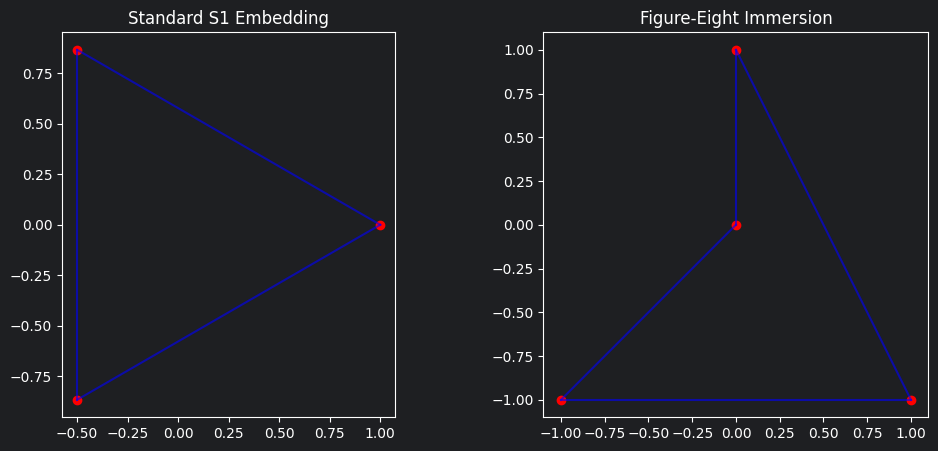

In [8]:
# Helper function to plot a 1D complex in 2D
def plot_pl_map_2d(pl_map, ax, title):
    coords = pl_map.vertex_coordinates
    for s_idx in range(pl_map.source_complex.count_simplices(1)):
        v_indices = pl_map.source_complex.n_simplices(1)[s_idx]
        p1, p2 = coords[v_indices[0]], coords[v_indices[1]]
        ax.plot([p1[0], p2[0]], [p1[1], p2[1]], 'b-', alpha=0.6)
    
    ax.scatter(coords[:,0], coords[:,1], color='red')
    ax.set_title(title)
    ax.set_aspect('equal')

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
plot_pl_map_2d(pl_map, axes[0], 'Standard S1 Embedding')
plot_pl_map_2d(pl_map_8, axes[1], 'Figure-Eight Immersion')
plt.show()

## Part 4: Higher Dimensions and the Whitney Trick

In higher dimensions (codimension $\ge 3$), most self-intersections are "isolated points" that can be moved and cancelled. In `pySurgery`, we use `analyze_embedding` to verify if these obstructions vanish.


### Example 17.3: Projecting a Surface into $\mathbb{R}^3$

In [11]:
# Mobius Strip or Torus projection
torus = ps.SimplicialComplex.from_maximal_simplices([
        (0, 3, 4), (0, 1, 4),
        (1, 4, 5), (1, 2, 5),
        (2, 3, 5), (0, 2, 3),
        (3, 6, 7), (3, 4, 7),
        (4, 7, 8), (4, 5, 8),
        (5, 6, 8), (3, 5, 6),
        (0, 1, 6), (1, 6, 7),
        (1, 2, 7), (2, 7, 8),
        (0, 2, 8), (0, 6, 8),
])

# Generate some 3D coordinates (spiral)
n_v = torus.f_vector()[0]
theta = np.linspace(0, 4*np.pi, n_v)
z = np.linspace(-1, 1, n_v)
coords_3d = np.column_stack([np.cos(theta), np.sin(theta), z])

pl_map_3d = PLMap.from_source(torus, coordinates=coords_3d)
res_3d = analyze_embedding(torus, coordinates=coords_3d)

print('3D Surface Mapping:')
print(f'  Is Immersion? {res_3d.immersion.immersed}')
print(f'  Number of self-intersections: {len(res_3d.intersections)}')

3D Surface Mapping:
  Is Immersion? True
  Number of self-intersections: 51


## Failure Modes

1. **Degenerate Simplices**: If a simplex (like a triangle) is mapped to a line or a point in the target space, the map fails to be an immersion.
2. **Boundary Intersections**: Intersections occurring exactly on the boundary of simplices require high-precision tolerance (`tol`) to detect correctly.
3. **High Codimension Complexity**: As the dimension of the target space increases, the combinatorial search for intersections grows significantly.


In [12]:
# Triggers a degenerate immersion error
degenerate_coords = np.zeros((3, 2)) # All vertices to origin
pl_map_deg = PLMap.from_source(sc_s1, coordinates=degenerate_coords)
res_deg = analyze_embedding(sc_s1, coordinates=degenerate_coords)

print(f'Degenerate Map - Is Immersion? {res_deg.immersion.immersed}')
print(f'Result Summary: {res_deg.summary}')

Degenerate Map - Is Immersion? False
Result Summary: PL embedding/immersion analysis incomplete or obstructed.


## Summary Checklist
- [x] Represented source complexes and target coordinates via `PLMap`.
- [x] Verified local injectivity using `check_immersion`.
- [x] Detected global self-intersections in 2D and 3D mappings.
- [x] Visualized the difference between standard embeddings and self-intersecting immersions.
- [x] Handled degenerate cases where simplices collapse in the target.

## Exercises
1. **The Knot**: Build a PL map of a circle into $\mathbb{R}^3$ that represents a trefoil knot. Verify it is an embedding.
2. **Mobius Crossing**: Map a Mobius strip into $\mathbb{R}^2$. How many self-intersections do you find?
3. **Precision Test**: Create two simplices that are $10^{-7}$ apart and see if `detect_self_intersections` identifies them as disjoint using the default tolerance.
4. **Dimension Scaling**: Measure the time taken to detect self-intersections as you increase the number of simplices in a surface.
5. **Whitney Pairs**: Identify a pair of self-intersection points in a 2D immersion that have opposite local signs (conceptual).

## Key Takeaways
- **Embedding** is the gold standard for representing homology classes geometrically.
- **Immersions** are easier to construct but carry "obstructions" in the form of self-intersections.
- `pySurgery` provides rigorous combinatorial checks for **PL injectivity**.
- The **Whitney Trick** is the bridge between algebra (cancellation of signs) and geometry (removal of crossings).

**Ready for [18 - Intrinsic Dimension Estimators in Context](./18_intrinsic_dimension_estimators_in_context.ipynb)**
